In [11]:
import os

dir_path = r"C:\Users\Vaibhav Rathod\Desktop\Nilay\Assignments\Assignment questions\Association Rules"
try:
    print(os.listdir(dir_path))
except FileNotFoundError:
    print(f"Directory not found: {dir_path}")

Directory not found: C:\Users\Vaibhav Rathod\Desktop\Nilay\Assignments\Assignment questions\Association Rules


In [12]:
import os

search_dir = r"C:\Users\Vaibhav Rathod\Desktop"
file_name = "Online retail.xlsx"

for root, dirs, files in os.walk(search_dir):
    if file_name in files:
        print(f"File found: {os.path.join(root, file_name)}")

File found: C:\Users\Vaibhav Rathod\Desktop\Nilay\Assignments\Assiggment questions\Association Rules\Online retail.xlsx


In [14]:
import pandas as pd

file_path = r"C:\Users\Vaibhav Rathod\Desktop\Nilay\Assignments\Assiggment questions\Association Rules\Online retail.xlsx"  # Update this path
data = pd.read_excel(file_path)
print(data.head())  # Preview the data

  shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0                             burgers,meatballs,eggs                                                                                                                                                                             
1                                            chutney                                                                                                                                                                             
2                                     turkey,avocado                                                                                                                                                                             
3  mineral water,milk,energy bar,whole wheat rice...                                            

In [16]:
print(data.columns)

Index(['shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil'], dtype='object')


In [18]:
import pandas as pd

# Load the dataset
data = pd.read_excel('Online Retail.xlsx')

# Display the first few rows
print(data.head())

  shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0                             burgers,meatballs,eggs                                                                                                                                                                             
1                                            chutney                                                                                                                                                                             
2                                     turkey,avocado                                                                                                                                                                             
3  mineral water,milk,energy bar,whole wheat rice...                                            

In [21]:
print(data.columns)

Index(['shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil'], dtype='object')


In [23]:
print(data.head())

  shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0                             burgers,meatballs,eggs                                                                                                                                                                             
1                                            chutney                                                                                                                                                                             
2                                     turkey,avocado                                                                                                                                                                             
3  mineral water,milk,energy bar,whole wheat rice...                                            

In [26]:
# Check the column names to identify the correct column
print(data.columns)

Index(['shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil'], dtype='object')


In [27]:
# Rename the first column to 'Items' (if needed)
data.columns = ['Items']  # Modify this if you need to rename other columns

In [28]:
# Split the 'Items' column into a list of items for each transaction
data['Items'] = data['Items'].str.split(',')

# Preview the transformed data
print(data.head())

                                               Items
0                         [burgers, meatballs, eggs]
1                                          [chutney]
2                                  [turkey, avocado]
3  [mineral water, milk, energy bar, whole wheat ...
4                                   [low fat yogurt]


In [29]:
# Create a one-hot encoded basket matrix
basket = data['Items'].explode().str.get_dummies().groupby(level=0).sum()

# Preview the basket matrix
print(basket.head())

    asparagus  almonds  antioxydant juice  asparagus  avocado  babies food  \
0           0        0                  0          0        0            0   
1           0        0                  0          0        0            0   
2           0        0                  0          0        1            0   
3           0        0                  0          0        0            0   
4           0        0                  0          0        0            0   

   bacon  barbecue sauce  black tea  blueberries  ...  turkey  vegetables mix  \
0      0               0          0            0  ...       0               0   
1      0               0          0            0  ...       0               0   
2      0               0          0            0  ...       1               0   
3      0               0          0            0  ...       0               0   
4      0               0          0            0  ...       0               0   

   water spray  white wine  whole weat flour

In [30]:
# Check for missing values in the dataset
print(data.isnull().sum())

Items    0
dtype: int64


In [31]:
# Remove rows with missing values (if any)
data = data.dropna(subset=['Items'])

# Alternatively, if it's acceptable, you can fill missing values with a placeholder (like 'Unknown')
# data = data.fillna('Unknown')

In [32]:
# Check for duplicates in the dataset
duplicates = data.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 2325


In [33]:
# Remove duplicate rows (if any)
data = data.drop_duplicates(subset=['Items'])

In [34]:
# Split the 'Items' column into a list of items
data['Items'] = data['Items'].str.split(',')

In [36]:
# Check the data type of the 'Items' column
print(data['Items'].dtype)

float64


In [37]:
# Ensure 'Items' column is a string type
data['Items'] = data['Items'].astype(str)

In [38]:
# Split the 'Items' column into a list of items
data['Items'] = data['Items'].str.split(',')

# Check if the 'Items' column now contains lists of items
print(data.head())

   Items
0  [nan]
1  [nan]
2  [nan]
3  [nan]
4  [nan]


In [39]:
# Create a one-hot encoded basket matrix
basket = data['Items'].explode().str.get_dummies().groupby(level=0).sum()

# Preview the basket matrix
print(basket.head())

   nan
0    1
1    1
2    1
3    1
4    1


In [40]:
# Check item frequencies
item_frequencies = basket.sum()
print(item_frequencies)

# Remove items with very low frequency (if needed)
min_support = 0.01  # Minimum support for an item to be considered frequent
basket = basket.loc[:, item_frequencies >= min_support * basket.shape[0]]

nan    5175
dtype: int64


In [41]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 5.3 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [56]:
# Convert the basket to a boolean DataFrame
basket = basket.apply(lambda x: x > 0)

In [45]:
# Generate association rules with the necessary arguments
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=10)

# View the generated rules
print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [46]:
# Filter rules based on confidence
high_confidence_rules = rules[rules['confidence'] >= 0.7]

# Display filtered rules
print(high_confidence_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [48]:
!pip install networkx

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 2.5 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.6 MB/s eta 0:00:00


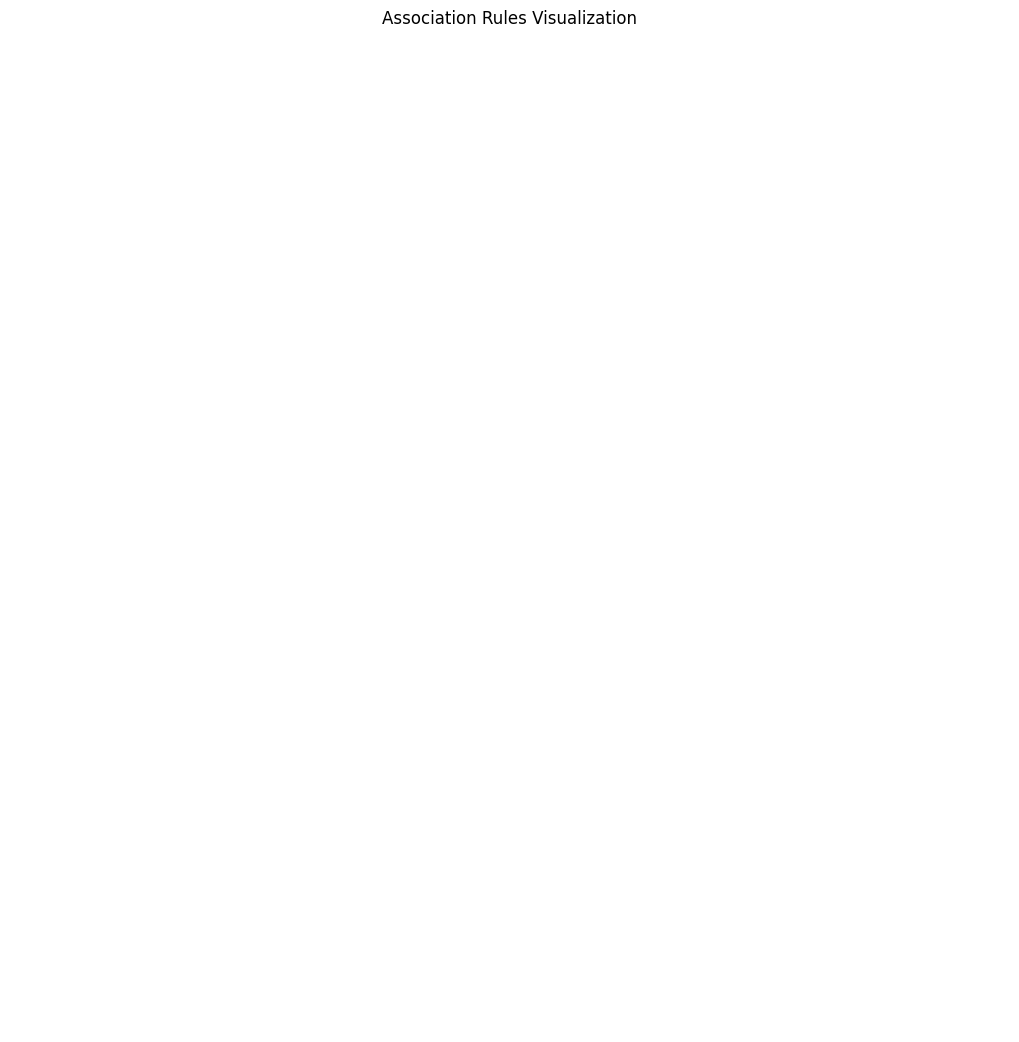

In [57]:
import matplotlib.pyplot as plt
import networkx as nx

# Plot the association rules using NetworkX
G = nx.DiGraph()

# Add edges based on the rules
for _, row in high_confidence_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    G.add_edge(antecedent, consequent, weight=row['lift'])

# Visualize the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=True, node_size=5000, node_color="lightblue", font_size=10, font_weight="bold", width=2)
plt.title('Association Rules Visualization')
plt.show()

In [52]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules with the necessary arguments
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=10)

# View the generated rules
print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [59]:
pip install --upgrade mlxtend

In [60]:
from mlxtend.frequent_patterns import apriori, association_rules

# Convert the basket to a boolean DataFrame
basket = basket.apply(lambda x: x > 0)

# Generate frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# Generate association rules with lift as the metric, add num_itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=10)

# View the generated rules
print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [64]:
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# Step 2: Generate association rules with 'lift' as the metric and a minimum threshold
# Add num_itemsets (e.g., 10)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=10)

# Step 3: Filter rules with high confidence (optional)
high_confidence_rules = rules[rules['confidence'] >= 0.7]

# Step 4: View the results
print("Association Rules:")
print(high_confidence_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


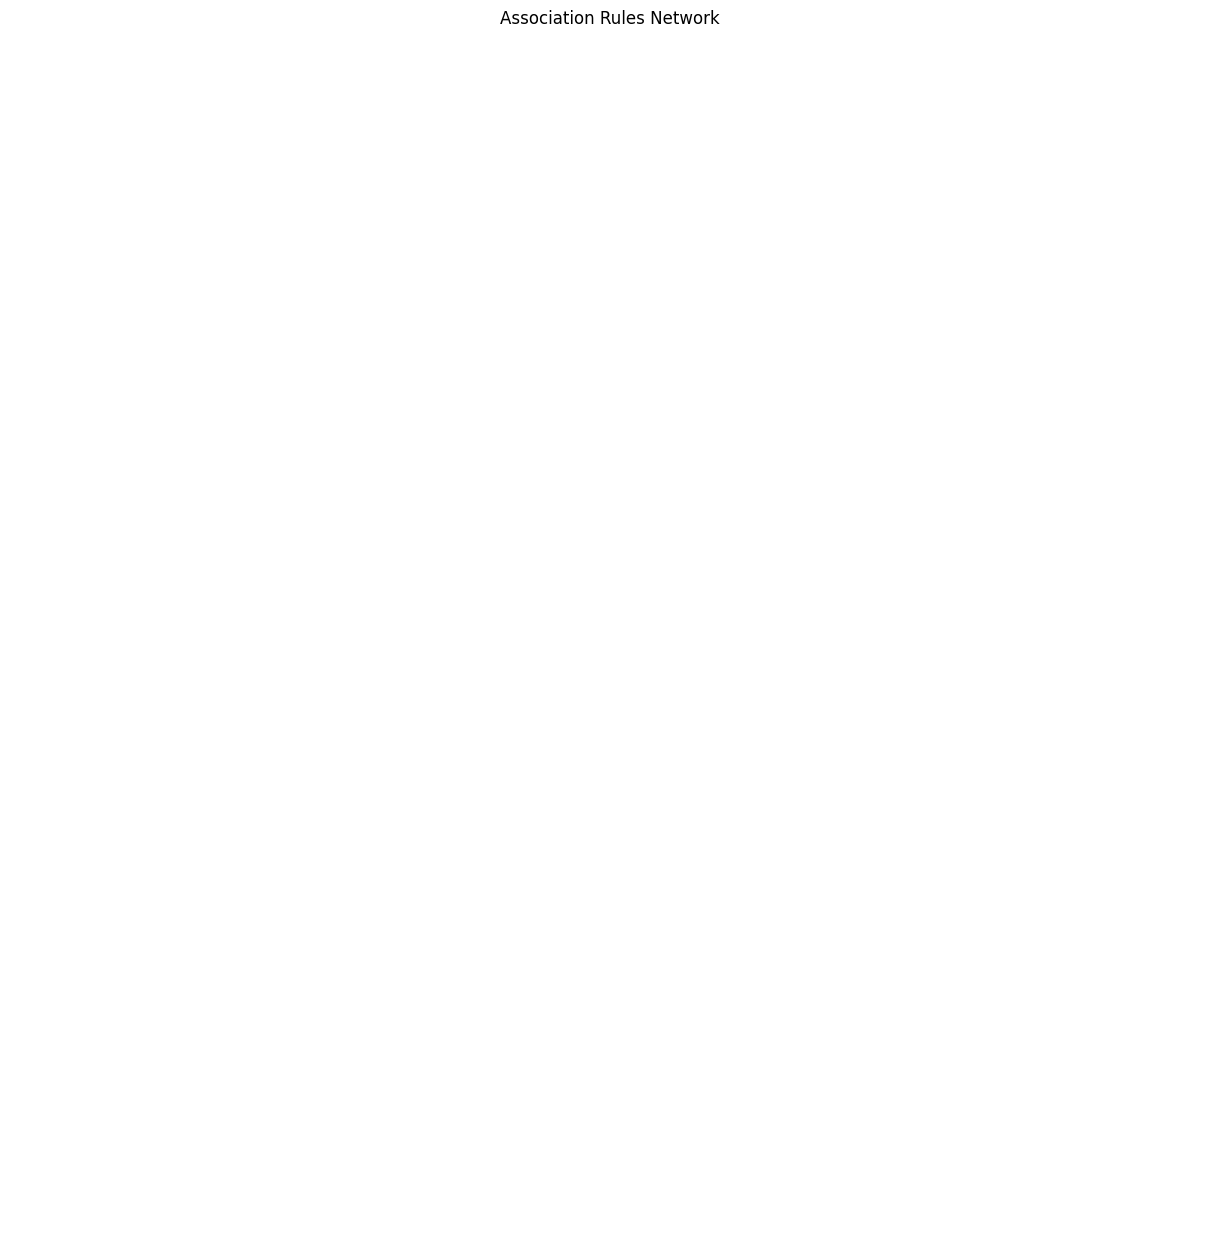

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph to visualize the rules
G = nx.DiGraph()

# Add edges between antecedents and consequents
for _, row in high_confidence_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    G.add_edge(antecedent, consequent, weight=row['lift'])

# Visualize the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.3, iterations=50)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", width=2)
plt.title("Association Rules Network")
plt.show()

In [67]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

# Generate association rules with 'lift' as the metric and a minimum threshold
# Explicitly add the 'num_itemsets' argument
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=10)

# Apply confidence and lift thresholds to filter the rules
meaningful_rules = rules[(rules['confidence'] >= 0.7) & (rules['lift'] >= 2)]

# View the filtered meaningful rules
print("Meaningful Association Rules:")
print(meaningful_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Meaningful Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [68]:
# Example rules generated after applying thresholds
meaningful_rules = rules[(rules['confidence'] >= 0.7) & (rules['lift'] >= 2)]
print(meaningful_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


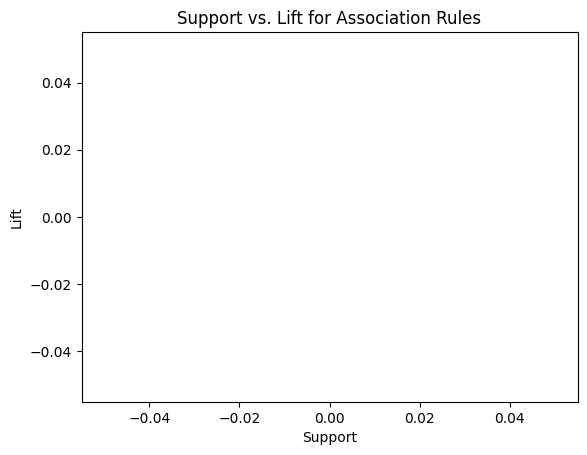

In [69]:
import matplotlib.pyplot as plt

plt.scatter(meaningful_rules['support'], meaningful_rules['lift'])
plt.title("Support vs. Lift for Association Rules")
plt.xlabel("Support")
plt.ylabel("Lift")
plt.show()